In [2]:
#Import the libraries
import pandas as pd 
import numpy as np 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error ,mean_squared_error ,r2_score
import pickle
 

In [4]:
#Load processed Data 
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# Show the shape X dara [train,test]
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (240, 7)
Test size: (61, 7)


In [5]:
#Training Random Forest model
model =RandomForestRegressor(
    n_estimators =100,
    random_state=42
)

model.fit(X_train,y_train)
print("Model trained successfully!")

Model trained successfully!


In [7]:
#Evaluate model
y_pred = model.predict(X_test)

mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)

#print the Evalutation 
print("Model Evaluation")
print(f"MAE : {mae:.2f}")
print(f"RMsE : {rmse:.2f}")
print(f"R2 : {r2:.2f}")

Model Evaluation
MAE : 0.61
RMsE : 0.92
R2 : 0.96


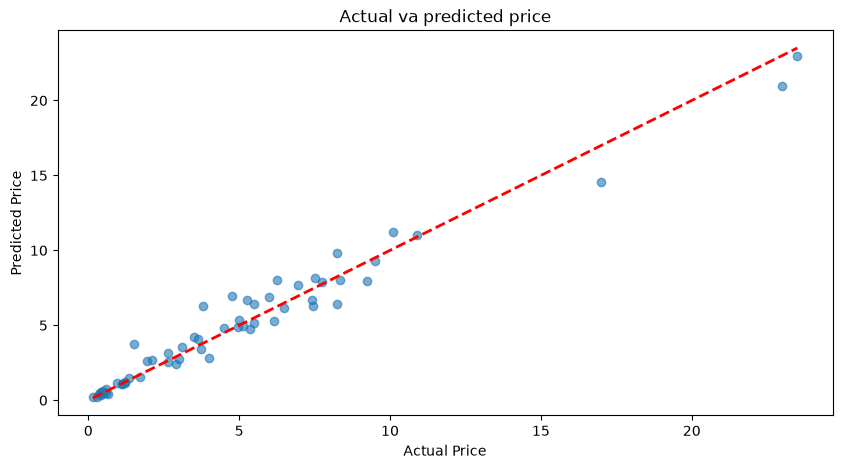

In [11]:
# Comparing actual values ​​with expected values
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         'r--' ,linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual va predicted price')
plt.show()

In [10]:
# Save model
with open('../models/car_price_model.pkl','wb')as f:
    pickle.dump(model,f)

print("Model saved to models/car_price_model.pkl")


Model saved to models/car_price_model.pkl
